# DWDM Laser Array Optical Frequency and Power Control Algo

### _Xing Pan , 01/03/2025_
### _updated: 5/18/2025: add VOA in the formulation_
### _updated: 4/5/2026: added notes on performaing frequency estimation/control in a feed-forward fashion and not relying on dither
## Introduction

We propose a cost function for DWDM optical frequency and power control/optimization. 

$$
F = \frac{1}{f_{BW}^2}\sum_{i=0}^{15}(f_i-f_{tgt,i})^2 + \frac{1}{P_{BW}^2}\sum_{i=0}^{15}(P_i-P_{tgt,i})^2+B_T(T_{PIC})+\\
\sum_{i=0}^{15}B_{LD}(I_{i})+\sum_{i=0}^{15}B_{VOA}(I_{VOAi})
$$

* $f_i$ channel $i$ frequency, $f_{tgt,i}$ target frequency for channel $i$;
* $P_i$ channel $i$ power, $P_{tgt,i}$ target power for channel $i$;
* $f_{BW}$, $P_{BW}$ provide weights/normalization/scaling to frequency and power error. Setting $P_{BW}=\infty$ means only frequency are controlled.
* $B_T$, $B_{LD}$ and $B_{VOA}$ are 'bathtub' functions introduced so the PIC temp, LD bias currents and VOA currents are kept away from their specified min max range _gracefully_. This point will be discussed in more detail later.

The goal of CLM control is to minimize the cost function $F$.


Ignoring, for the moment, the 'bathTub' terms:
$$
F = \frac{1}{f_{BW}^2}\sum_{i=0}^{15}(f_i-f_{tgt,i})^2 + \frac{1}{P_{BW}^2}\sum_{i=0}^{15}(P_i-P_{tgt,i})^2
$$

The goal of  control is to minimize the cost function $F$ by adjusting the control variables (laser, VOA bias currents, PIC TEC temperature).


$F$ is a function of control variables 
* $I=[I_0, ..., I_{15},I_{VOA0}, ..., I_{VOA15}]^T$. $I_i, i=0, 1, 2, ..., 15$ is laser bias current. $I_i, i=16, ...32$ are VOA bias currents.
* $T_{PIC}$ $PIC$ temperature , which is actively controlled in a TEC PID loop.

Derivative of $F$ with respect to a control variable $I_j$, at current state $f_{i0}, P_{i0}, i=0, ...15$:

$$
\frac{dF}{dI_j}=\frac{1}{f_{BW}^2}\sum_{i=0}^{15}2(f_{i0}-f_{tgt,i})\frac{df_i}{dI_j} + \frac{1}{P_{BW}^2}\sum_{i=0}^{15}2(P_{i0}-P_{tgt,i})\frac{dP_i}{dI_j}, j=0, 1, 2 ..., 16
$$

In the above, for clarity, we have ignored the the 'bath tub' function, which will be discussed later. $\frac{df_i}{dI_j}$ ($i$'th channel frequency change vs $j$'th control variable) can be estimated/calibrated and is largly constant over a laser's normal operating conditions. For optical power, we may only need to consider the $i=j$, $\frac{dP_i}{dI_i}$ term (slope of LI curve). 

The above formula can be simplified if we ignore cross-talk between channels:

$$
\frac{dF}{dI_i}=\frac{1}{f_{BW}^2}2(f_{i0}-f_{tgt,i})\frac{df_i}{dI_i} + \frac{1}{P_{BW}^2}2(P_{i0}-P_{tgt,i})\frac{dP_i}{dI_i}, i=0, 1, 2 ..., 15
$$

ignore frequency tuning of VOA and  channel cross-talk, derivative of cost function with respect to VOA can be written as:
$$
\frac{dF}{dI_i}=\frac{1}{P_{BW}^2}2(P_{i0}-P_{tgt,i})\frac{dP_i}{dI_i}, i=16, 17, 18 ..., 31
$$

VOA attenuation can be expressed by the emperical formula:

$$
Attn=\frac{1}{1+aI_{VOA}}=\frac{1}{1+0.063I_{VOA}}
$$
, with this, we can write the cost function derivative w respect to VOA bias as:

$$
\frac{dF}{dI_i}=-\frac{1}{P_{BW}^2}2(P_{i0}-P_{tgt,i})\frac{P_{i0}}{(1+0.063I_{VOA})}, i=16, 17, 18 ..., 31
$$

derivative of cost function with respect PIC temp:
$$
\frac{dF}{dT}=\frac{1}{f_{BW}^2}\frac{df}{dT}\sum_{i=0}^{15}2(f_{i0}-f_{tgt,i})
$$
, the weak power dependence on PIC temperature is ignored and also assumed constant thermal tuning rate over channels. from test data, $\frac{df}{dT}=-16 GHz/C$

* **With the $\frac{df_i}{dI_j}$ and $\frac{P_i}{dI_j}$ values known/specified, the derivative of the cost function with respect to a control variable $\frac{dF}{dI_j}$ and $\frac{dF}{dT}$ can be computed easily.** 

* **PID loop(s), with $\frac{dF}{dI_j}$, $\frac{dF}{dT}$ as error signal, and $I_j$, $T_{PIC}$ as control variable can be implemented with the goal to drive the derivative to 0 (by default), or a non-zero setpoint**

## Laser Frequency and Power Estimate

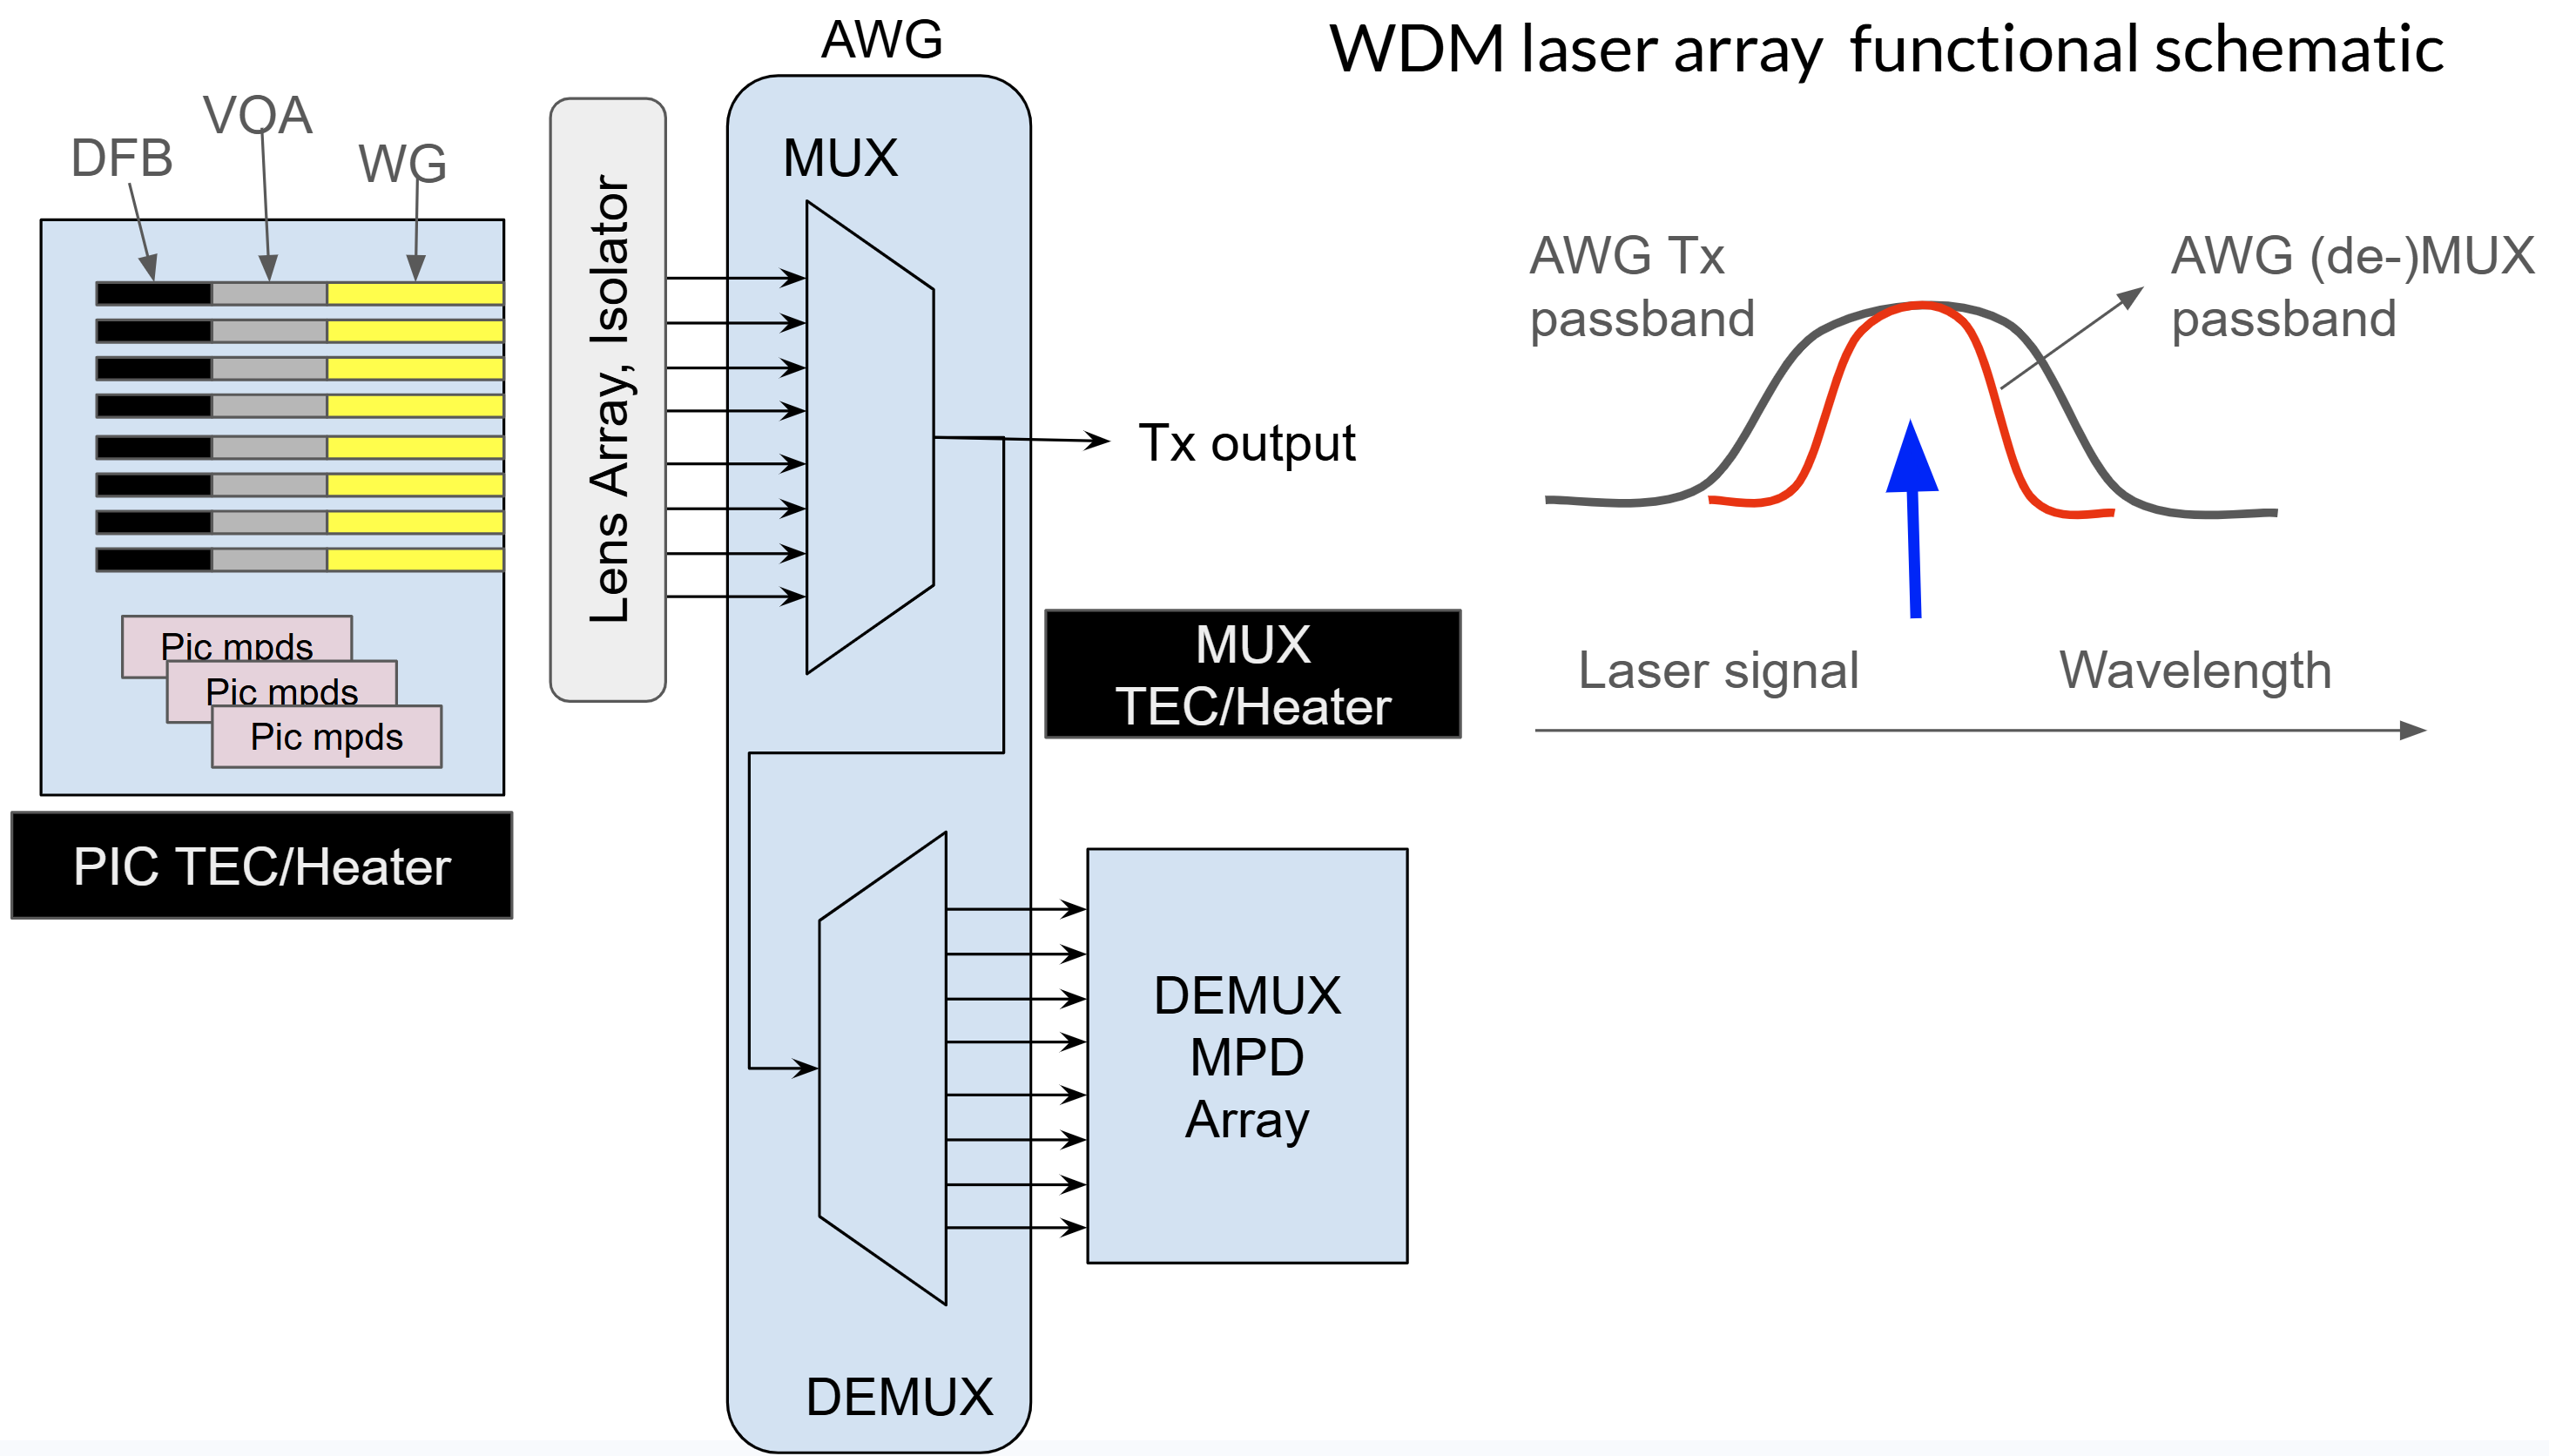

After calibration, a laser's output referred optical power can be estimated by the PIC or MUX MPD photo current directly.  
Optical frequency at or near the peak of the (de-)MUX transmission, on the other hand, is not measured directly. Instead, channel frequency (error) is estimated from the (de-)MUX MPD current dericvative with respect to (de-)MUX center frequency. 

(de)-MUX transfer function around ist center frequency:
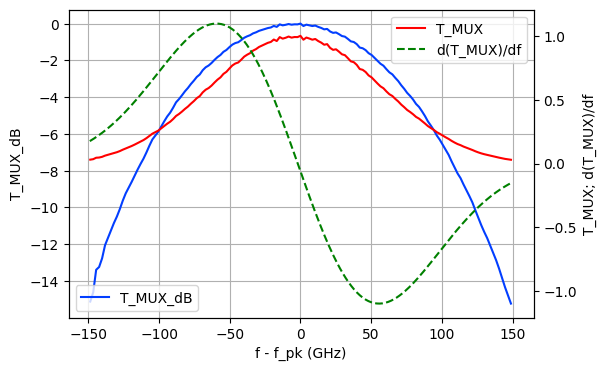

Blue trace shows the transfer function in dB of one channel around the peak. Red curve is the same in linear scale. Green dashed trace is the derivative of $T_{MUX}$ with respect to frequency (scaled up in y-axis so as to display it clearly). 
We see that over +/- 30 GHz range the curve is largly linear and therefore is suitable to be used for frequency estimation and control. 

In laser system operation, $MPD_{MUX}/MPD_{PIC}$ is a measure of the MUX transfer function and the 'derivative with respect to frequency' is achieved causing small laser frequency shift by eidther dither the laser bias current or the PIC temperature or the MUX temperature. 

The advantage of dither MUX temperature is that the laser frequency and power is not (ideally) not changed. This is currently implemented in Guide1.


## Implementation Details

Let $MPD_{1,i}$ be the derivative of $MPD_{MUX}/MPD_{PIC}$ ofchannel $i$ with respect to frequency, and $MPD_{0,i}$ the MPD current of channel $i$.
We can re-write the cost function as:
$$
F = \frac{a^2}{f_{BW}^2}\sum_{i=0}^{15}MPD_{1,i}^2 + \frac{b^2}{P_{BW}^2}\sum_{i=0}^{15}(MPD_{0,i}-MPD_{tgt,i})^2
$$

$a$ and $b$ are constatants to scale/normalize the $MPD$ parameters to frequency error and power respectively. Drivative of the cost Function with respect to laser current $I_j$:
$$
\frac{dF}{dI_j} = \frac{2a^2}{f_{BW}^2}\sum_{i=0}^{15}MPD_{1,i}\frac{dMPD_{1,i}}{df_i}\frac{df_i}{dI_j} + \frac{2b^2}{P_{BW}^2}\frac{dMPD_{0,j}}{dI_j}(MPD_{0,j}-MPD_{tgt,j})
$$
If we ignore thermal crosstalk between lasers,
$$
\frac{dF}{dI_j} = \frac{2a^2}{f_{BW}^2}\frac{dMPD_{1,i}}{df_i}\frac{df_j}{dI_j}MPD_{1,i} + \frac{2b^2}{P_{BW}^2}\frac{dMPD_{0,j}}{dI_j}(MPD_{0,j}-MPD_{tgt,j})
$$

A good approximation is that TEC drive impact all channel frequency the same and no impact on channel power, which gives:
$$
\frac{dF}{dI_{16}} = \frac{2a^2}{f_{BW}^2}\frac{df}{dI_{16}}\sum_{i=0}^{15}MPD_{1,i}
$$

_Initially we will use the above two equations ('model')_ for clm control. Below, we discuss how to arrive at numerical values to various terms
* $MPD_{0,j}$: DC PIC MPD current for channel $j$. $MPD_{tgt,j}$ is then the MPD current corresponding to desired output power.
* $b = \frac{1}{tapLoss*Responsivity}$;
*  _For control purpose_, $\frac{dMPD_{0,j}}{dI_j}$ is assumed to be a constant over channels and over laser bias, and its value estimated from a linear fit of LI sweep, $MPD$ vs. LD bias data.
*  $MPD_{1,i}$ is estimated by dither channel $j$ LD bias current and compute:

$$
    MPD_{1,j}=\frac{dy}{df}=\frac{dy}{dI_j}\frac{dI_j}{df} \\
y=\frac{MPD_{MUX}}{MPD_{PIC}}
$$
* $\frac{dy}{dI_j}$ is directly measured during clm dither operation:

$$
\frac{dy}{dI_j}=\frac{\Delta y}{\Delta I_j}
$$

* $\frac{dI_j}{df}$ is estimated from clm calibration/measurement. For example, based on measured data, $\frac{df}{d(IV)}=-1$ $GHz/mW$. Assuming a LD voltage of 2V, we get $\frac{df}{dI}=-0.5$ $GHz/mA$.  Or $\frac{dI}{df}=-2$ $mA/GHz$ (Note again, for control purpose, the number needs not to be very precise.)

* how to determin the scaling factor '$a$' above. We want, around MUX transmission peak, $aMPD_{1,j}$ is a good estimation of frequency offset from MUX peak, ie.:
  
  $$
  aMPD_{1,j}(f)=a[MPD_{1,j}(f_{pk}) + \frac{dMPD_{1,j}}{df})(f - f_{pk})]=a\frac{dMPD_{1,j}}{df}(f - f_{pk})=(f - f_{pk})  
  $$

* so $a=1/\frac{dMPD_{1,j}}{df}$ estimated at $f = f_{pk}$. This can be done through calibration

* Lastly, $\frac{df}{dI_{16}}$ can be estimated from a $T_{PIC}$ sweep.  
  

dfdT_PIC, dWavelengthdT_PIC:
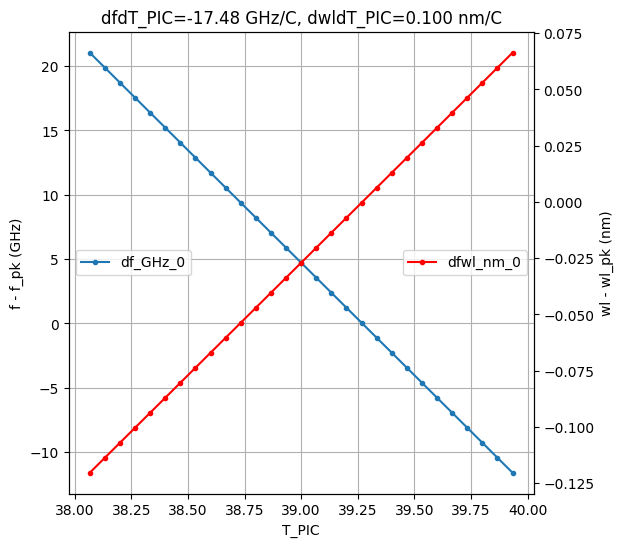

## Note on the 'bath tub' functions

It has the property that:


$$
\frac{d(bathTub_T)}{dT} =
\begin{cases}
    <0, & T_{PIC} < T_{min}+\delta T \\
    0, & T_{min}+\delta T \leq T_{PIC}  \leq  T_{max}-\delta T \\
    >0, & T_{PIC}  >  T_{max}-\delta T
\end{cases}
$$

i.e. the 'bath tub' function normally has no impact on the laser system control, when $T_{PIC}$ is within the specified temperature range. When the PIC temp gets too close to $T_{min}$ or $T_{max}$, the 'bath tub' function will add a artificially generated error signal to push the $I_{16}$ and hence  $T_{PIC}$ away from the boundary.

__Currently, the 'bath tub' feature is not implemented in Guide1 FW.__

## Discussion

Basing DWDM laser array control on a single cost function that include contributions of all channels and both optical frequency and power errors has several benefits:

* Since laser current changes both it's frequency and power, in general, for a given channel, both laser frequency and power can not converge to to specificed targets at the same time; Also, there is channel thermal X-talk. Changing one channel's bias current impact (to a lesser degree) other channels. Having a single cost function takes all these into consideration and the control loop will _naturally_ converge to the global optimum ('in the least square sense')
* In real application, all channel frequency, power estimates/measurements are subject to noise. A cost function that sums the contributions of all channels has the effect of average out random noise. This should make the control loop more stable, not over react to noise or transcients
* Simple/simplified control logic:
  * We may not need a separate $T_{PIC}$ sweep stage at startup. Simply enable the control loop at a reasonable CML initial state, the $T_{PIC}$ should converge to the right spot:

$$ 
\frac{dF}{dI_{16}}=\frac{2df/dI_{16}}{f_{BW}^2}\sum_{i=0}^{15}(f_{i0}-f_{tgt,i})=0
$$

    i.e. the control will drive the PIC temp to where the sum of frequency error over all channels is zero, which is what we want. (we assumed in the above all lasers' frequency change the same rate with respect to PIC TEC drive, a reasonable assumption)

* Considering channel X-talk:
       $$
          \frac{dF}{dI_j}=\frac{2}{f_{BW}^2}\sum_{i=0}^{15}(f_{i0}-f_{tgt,i})\frac{df_i}{dI_j}
       $$

$| \frac{df_i}{dI_i}| > |\frac{df_i}{dI_j}| , j \neq i$. If the 'self channel' and neighboring channels frequency error are of similar values, the cost function slope (and hence feedback setp size) is mainly due to 'self channel'; If on the other hand, the 'self channel' frequency error is small, the neighboring channel's contributions will be weighted more. And the 'self channel' will be _nice_, adjust in such a way as to benefit the 'worse off' neighboring channel(s). Quite a reasonable behavior. 

## Effect of MUX Temperature Dither and Laser Control without Mux Dither

As stated before, one advantage of laser frequency estimation using MUX dither is that, as opposed to dithering laser bias current or PIC tempperature,  the laser frequency is not changed. 

In actually Guide1, there is tiny bit of laser frequency change due to MUX temperature dither as shown below:


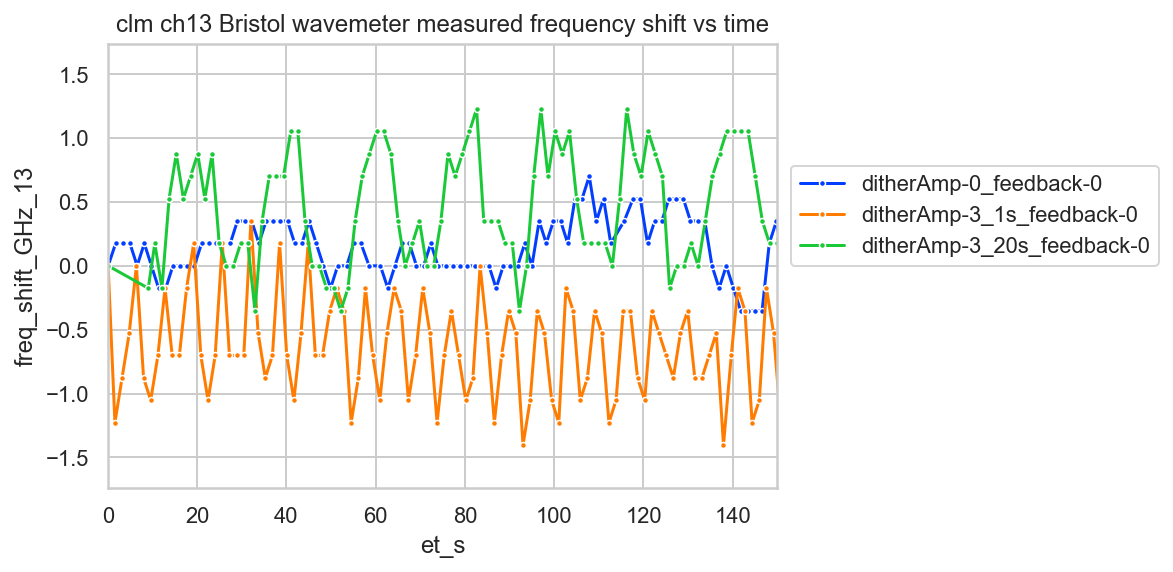

Guilde1 laser channel 13 frequency change vs. time measured with a Bristol wavemeter
* Blue trace: laser free running (meaning: no MUX dither, not feedback control)
* Brown trace: MUX dither 3C peak-to-peak, 1s dither period, no feedback control
* Green trace: MUX dither 3C peak-to-peak, 20s dither period, no feedback control

The data suggests that MUX temperature dither does leads to small amount of laser frequency shift. We suspect the mechanism of the 'MUX dither induce frequency shift' is like this:
* MUX temperature dither results in heat being pumped in and out of the heat sink periodically
* Since the PIC and MUX share the same heat sink, this theat flow leads to small change in PIC temp which in turn leads to the frequency shift seen.
It is known that 1C change in PIC temp leads to -16 GHz frequency shift, 1 GHz frequency shift corresponds to 0.06C PIC temp change. Thhe propose mechanis suggests there is $0.06/3=2\%$ thermal X-talk between MUX and PIC.

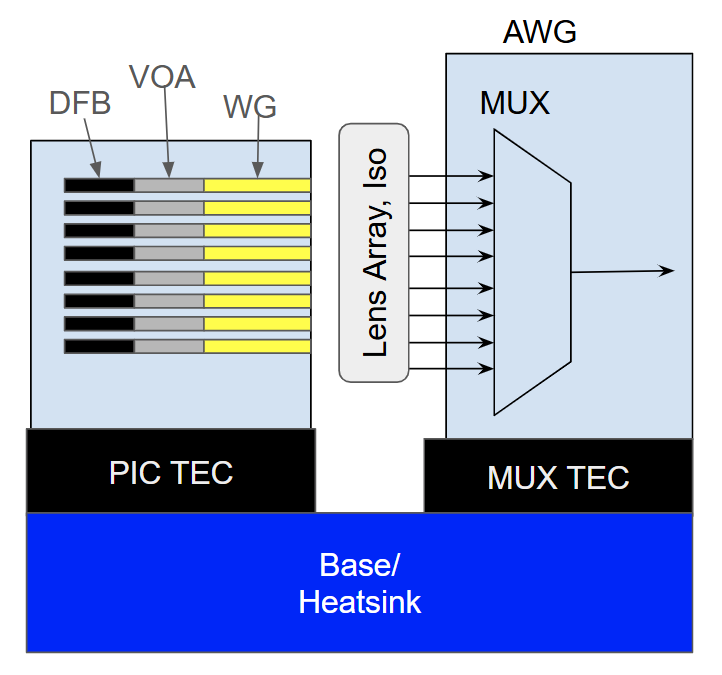

We belive down stream system control should be able to accommodate this level of frequency fluctuation.

However, if we suspect MUX dither may be an issue, we can perform laser control without MUX dither relying on the fact that laser frequency change with respect to PIC temp and laser bias current is predicatable and largely linear. We can estimate the laser array's present frequencies from it's present PIC temperature and laser bias currents.

Let $f_{0i}$ be the initial channel frequency with laser bias current $I_{0i}$ and PIC temp $T_{PIC0}$. This prior knowledge can be based on calibration test, and/or result of initial laser control with MUX dither enabled. Laser frequencies at $I_i$ and $T_{PIC}$ are estimated as:

$$
f_i = f_{0i} +\frac{df}{dT_{PIC}}(T_{PIC} - T_{PIC0})+\sum_{i=0}^{15}\frac{df_i}{dI_j}(I_j-I_{0j})
$$

The above channel frequency estimations are then 'plugged' into laser control algo.

For a good start, and ignore thermal X-talk between channels, in $GHz$ unit, we can use:
$$
f_i = f_{0i} -16(T_{PIC} - T_{PIC0}) - 0.8(I_i-I_{0i})
$$

Below are some earlier measurement data on guide1 laser that supports the case.


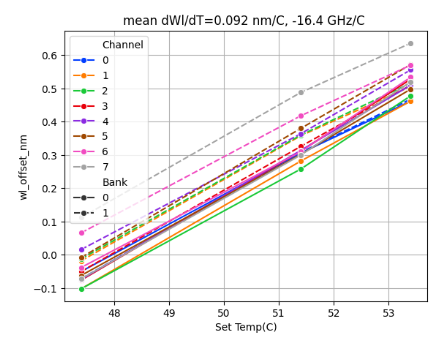

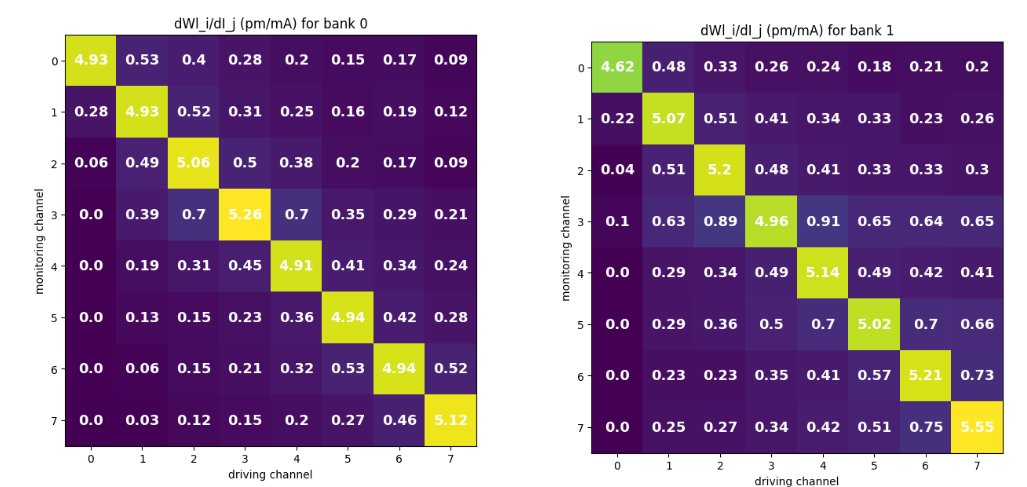